<a href="https://colab.research.google.com/github/ivanediazm/telecom-analysis/blob/main/telecom_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
---
 - `Users`:
- `city` tiene 469 valores nulos, equivalentes a 11.73%. Conviene investigar y después imputar o mantener como nulos, dependiendo de si la ciudad es relevante para el análisis. También puede tratarse de algún sentinel.
- `churn_date` tiene 3534 valores nulos, equivalentes a 88.35%. Aunque por porcentaje podría parecer candidata a eliminarse, aquí tiene sentido conservarla porque un valor nulo probablemente significa que el cliente no ha cancelado el servicio; por eso la mantendría sin imputar.
- El resto de columnas de users no presenta valores nulos.
 ---
- `Usage`:
- `date` tiene 50 valores nulos, equivalentes a 0.125%. Como es menos de 5%, es un caso pequeño; se puede dejar como nulo o imputar esas pocas filas si la fecha es indispensable para el análisis.
- `duration`: presenta 22,076 valores nulos (55.19%). Sin embargo, estos valores se concentran en los registros de tipo text, donde `duration` no aplica. Por lo tanto, no se recomienda imputar; los valores nulos deben conservarse como “no aplica”.
- `length`: presenta 17,896 valores nulos (44.74%). Estos valores corresponden principalmente a registros de tipo call, donde `length` no aplica. Por lo tanto, tampoco se recomienda imputar y deben mantenerse como nulos.
- De los 40,000 registros, se esperaría encontrar aproximadamente un valor nulo entre `duration` y `length` por fila, ya que cada registro corresponde a una llamada o a un mensaje. Sin embargo, la suma de nulos es de 39,972, por lo que existen 28 casos que no siguen este patrón esperado. Estos registros deben revisarse de forma individual, ya que podrían corresponder a filas donde ambas variables tienen valor o donde existe alguna inconsistencia en la captura. Por ello, no se recomienda imputarlos automáticamente sin antes identificar su condición.
- El resto de columnas de usage no presenta valores nulo
---
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` funciona como identificador único de los usuarios, por lo que las estadísticas como media o desviación estándar no tienen relevancia analítica.
- La columna `age` detectamos el valor -999 como sentinel, ya que no corresponde a una edad válida. Este valor distorsiona la media y especialmente la desviación estándar. Se recomienda reemplazarlo por un valor faltante o, según la estrategia definida, por la mediana de las edades válidas y posteriormente recalcular las estadísticas.

In [ ]:
usage[['id', 'user_id','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`funciona como índice e identificador único de los usuarios respectivamente, por lo que las estadísticas como media o desviación estándar no tienen relevancia analítica
- La columna`duration`: presenta valores entre 0 y 120, con una mediana de 3.5. El máximo es considerablemente mayor que el tercer cuartil, por lo que se recomienda revisar posibles outliers.
- La columna `length`: presenta valores entre 0 y 1490, con una mediana de 50. El máximo está muy alejado del tercer cuartil, lo que sugiere la presencia de posibles valores extremos que deben analizarse posteriormente.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores de {col}:")
    print(users[col].value_counts(dropna=False))


Valores de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- En la columna `city` se detectó el valor "?" en 96 registros (2.4%), lo que representa un sentinel y debe reemplazarse por un valor nulo. El resto de las categorías corresponden a ciudades válidas.
- En la columna `plan` no se observan valores inválidos. El plan Básico representa aproximadamente el 64.9% de los usuarios y Premium el 35.1%, mostrando una mayor concentración de clientes en el plan Básico.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))
print(usage['type'].unique())

text    22092
call    17908
Name: type, dtype: int64
['call' 'text']


- La columna `type` no presenta valores inválidos ni categorías inesperadas. Los 40,000 registros se distribuyen entre text (55.2%) y call (44.8%), por lo que la columna se considera consistente y no requiere limpieza.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
---
- Diagnóstico general de users

- En las columnas numéricas, user_id funciona únicamente como identificador, por lo que estadísticas como promedio, desviación estándar o cuartiles no tienen valor analítico. La columna age sí presenta un problema de calidad: se detectó el sentinel -999, que no representa una edad válida y además distorsiona la media y la desviación estándar. Acción: excluir -999 del cálculo y reemplazarlo con la mediana de las edades válidas.

- En las columnas categóricas, city contiene 96 registros con "?" (2.4%), que representan un sentinel o dato desconocido. Acción: reemplazar "?" por pd.NA para tratarlo correctamente como valor faltante. La columna plan no presenta valores inválidos; únicamente se observa que el plan Básico concentra aproximadamente 64.9% de los usuarios y Premium 35.1%. Acción: no requiere limpieza.

---
- Diagnóstico general de usage

- En las columnas numéricas, id y user_id son identificadores, por lo que sus estadísticas descriptivas no deben interpretarse como métricas de comportamiento. Las variables duration y length sí representan consumo real, pero presentan una gran cantidad de nulos debido a la estructura del dataset: duration aplica únicamente a llamadas y length únicamente a mensajes. Acción: conservar estos nulos, ya que son missing estructural y no representan errores de captura ni deben imputarse artificialmente. Además, tanto duration como length presentan valores máximos muy alejados de sus cuartiles, por lo que existen posibles valores extremos. Acción: analizarlos posteriormente mediante boxplots e IQR antes de decidir si son errores o consumos reales de usuarios.

- En la columna categórica type, los 40,000 registros están correctamente clasificados como text o call: aproximadamente 55.2% son mensajes y 44.8% llamadas. No se detectaron categorías inválidas. Acción: conservar la columna sin modificaciones.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se detectaron 40 fechas correspondientes a 2026, equivalentes al 1% de los usuarios. Debido a que el dataset contiene información únicamente hasta 2024, estas fechas se consideran fuera de rango y se recomienda convertirlas a NaT.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, los 39,950 registros con fecha válida corresponden a 2024 y no presentan años fuera de rango. Existen 50 registros sin fecha válida (0.125%), por lo que pueden mantenerse como nulos o eliminarse si la fecha es necesaria para el análisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
---
- `users['reg_date']`: Se detectaron 40 registros con año 2026, equivalentes al 1% de los 4,000 usuarios. Como la información del proyecto llega hasta 2024, estas fechas son futuras y se consideran errores de captura. Acción: convertir esas fechas a NaT para marcarlas como inválidas y excluirlas de análisis temporales que requieran una fecha correcta.
- `usage['date']`: Se encontraron 39,950 fechas válidas de 2024 y 50 registros sin fecha válida, equivalentes al 0.125% de los 40,000 registros. No se observan años fuera de rango entre las fechas válidas. Acción: mantener esos 50 registros como nulos si la fecha no es indispensable, o eliminarlos si el análisis depende directamente de la variable date.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999,'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024,'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
duration_missing_by_type = (usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))
print(duration_missing_by_type)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
length_missing_by_type = (usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))
print(length_missing_by_type)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Los valores nulos de duration y length presentan un patrón asociado a la variable type. Cuando el registro corresponde a una llamada (call), length tiende a estar ausente; mientras que cuando corresponde a un mensaje (text), duration tiende a estar ausente. Como la ausencia puede explicarse mediante una variable observable del dataset, se considera un caso de MAR (Missing at Random). Se recomienda mantener estos valores como nulos y no imputarlos, ya que su ausencia está relacionada con la naturaleza del tipo de registro.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index())

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on='user_id',how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [ ]:
columnas_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
columnas_categoricas = ['city','plan',]

print(user_profile[columnas_numericas].head(5))
print(user_profile[columnas_categoricas].head(5))

    age  cant_mensajes  cant_llamadas  cant_minutos_llamada
0  38.0            7.0            3.0                 23.70
1  53.0            5.0           10.0                 33.18
2  57.0            5.0            2.0                 10.74
3  69.0           11.0            3.0                  8.99
4  63.0            4.0            3.0                  8.01
       city     plan
0  Medellín   Basico
1      <NA>   Basico
2      CDMX   Basico
3    Bogotá  Premium
4       GDL   Basico


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

In [ ]:
user_profile['city'].value_counts(normalize=True) * 100

Bogotá      23.522562
CDMX        21.251820
Medellín    17.933042
GDL         13.100437
Cali        12.343523
MTY         11.848617
Name: city, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

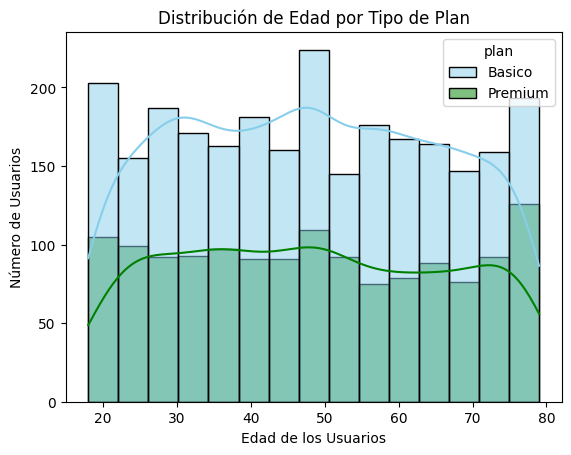

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    bins=15,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad de los Usuarios')
plt.ylabel('Número de Usuarios')
plt.show()

💡Insights:
- Plan Básico: concentra una mayor cantidad de usuarios en prácticamente todos los rangos de edad, con una presencia especialmente alta alrededor de los 45–50 años. Esto es consistente con que el plan Básico tiene una base de usuarios más grande.
- Plan Premium: presenta una distribución de edades bastante estable, aunque se observa una ligera mayor concentración entre aproximadamente 30 y 55 años. No parece estar enfocado únicamente en usuarios jóvenes o adultos mayores.
- Comparación entre planes: ambos planes tienen clientes distribuidos a lo largo de casi todo el rango de edad, por lo que no se observa una separación clara por edad entre Básico y Premium.
- Forma de la distribución: en ambos planes la distribución es relativamente simétrica, sin un sesgo fuerte hacia la derecha o hacia la izquierda. El plan Básico muestra un pico alrededor de los 45–50 años, mientras que Premium es más uniforme.

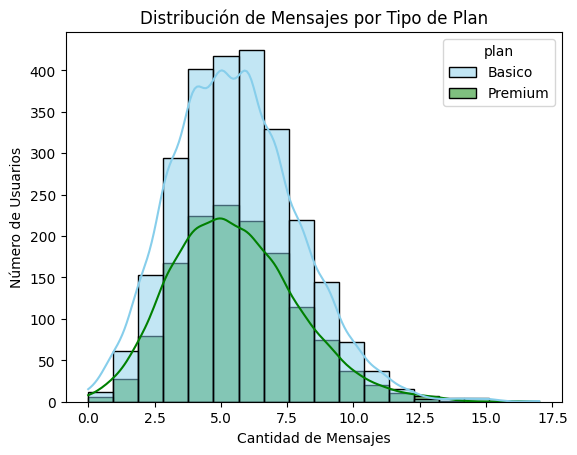

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    bins=18,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True)
plt.title('Distribución de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Número de Usuarios')
plt.show()

💡Insights:
- Concentración principal: En ambos planes, la mayoría de los usuarios envía aproximadamente entre 3 y 8 mensajes, con la mayor concentración alrededor de 5–6 mensajes.
- Comparación por plan: El plan Básico presenta más usuarios en prácticamente todos los rangos, pero esto no necesariamente significa que sus usuarios envíen más mensajes; el plan Básico tiene una base total de clientes mayor.
- Comportamiento similar: Las curvas KDE de Básico y Premium tienen una forma muy parecida, por lo que no se aprecia una diferencia fuerte en el comportamiento de envío de mensajes según el tipo de plan.
- Forma de la distribución: Ambas distribuciones presentan un ligero sesgo hacia la derecha, ya que la mayor parte de los usuarios se concentra alrededor de 4–7 mensajes, pero existe una cola hacia cantidades mayores, llegando a aproximadamente 15–17 mensajes. Los usuarios que envían más de 10–12 mensajes son relativamente pocos en ambos planes y podrían revisarse posteriormente como posibles casos de uso elevado.

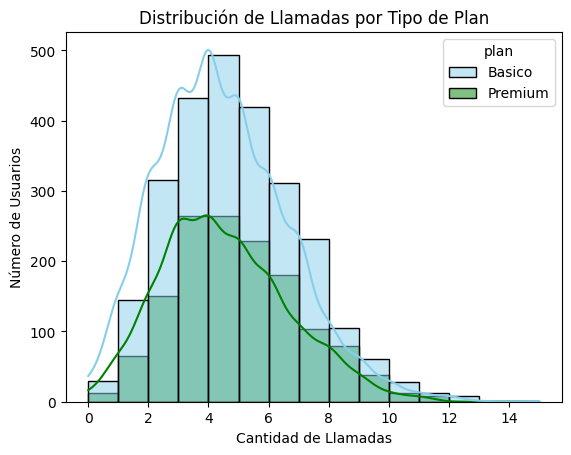

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    bins=15,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True)
plt.title('Distribución de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Número de Usuarios')
plt.show()

💡Insights:
- Concentración principal: La mayoría de los usuarios realiza aproximadamente entre 2 y 8 llamadas, con el mayor pico alrededor de 4–5 llamadas.
- Comparación por plan: El plan Básico presenta mayores conteos en casi todos los rangos, pero esto está influido por que tiene más usuarios en total. Las formas de las curvas de ambos planes son bastante similares.
- Forma de la distribución: Tanto Básico como Premium muestran una distribución sesgada a la derecha. La mayor parte de los usuarios se concentra en valores bajos o medios, mientras que existe una cola hacia cantidades más altas de llamadas.
- Usuarios de alto uso: Hay pocos usuarios con más de 10 llamadas, y los casos cercanos a 12–15 llamadas son poco frecuentes. Estos podrían revisarse posteriormente como posibles outliers o clientes de uso intensivo.
- Patrón por plan: No se observa una diferencia muy marcada entre Básico y Premium en la forma del comportamiento de llamadas; ambos siguen prácticamente el mismo patrón de distribución.

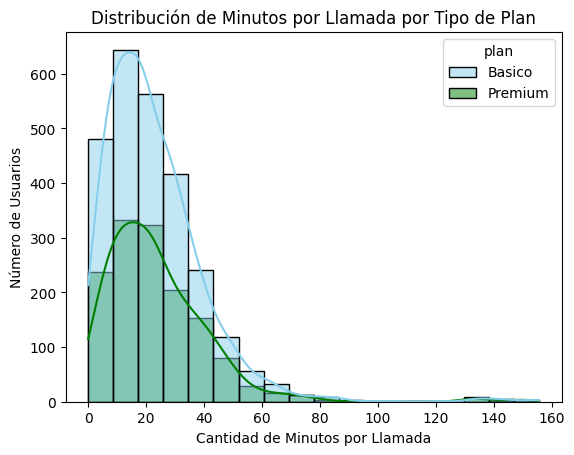

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    bins=18,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True)
plt.title('Distribución de Minutos por Llamada por Tipo de Plan')
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Número de Usuarios')
plt.show()

💡Insights:
- Concentración principal: La mayoría de los usuarios acumula relativamente pocos minutos de llamada, principalmente entre 0 y 40 minutos, con una mayor concentración alrededor de 10–20 minutos.
- Comparación por plan: Los planes Básico y Premium muestran una forma de distribución muy parecida. El Básico tiene mayores conteos absolutos porque tiene más usuarios, pero no se observa una diferencia fuerte en el patrón de consumo de minutos entre ambos planes.
- Forma de la distribución: La distribución está claramente sesgada a la derecha. La mayor parte de los usuarios se concentra en valores bajos, mientras que existe una cola larga hacia valores mucho más altos.
- Valores extremos: Se observan algunos usuarios con consumos cercanos a 130–150 minutos, muy alejados del comportamiento de la mayoría. Estos casos son candidatos claros para revisarse como posibles outliers.
- Implicación de negocio: Esos usuarios de consumo elevado podrían representar clientes intensivos que quizá necesiten un plan con mayor capacidad o beneficios específicos, por lo que conviene analizarlos antes de eliminarlos como valores atípicos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

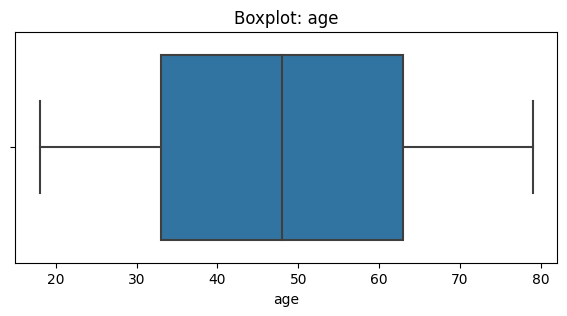

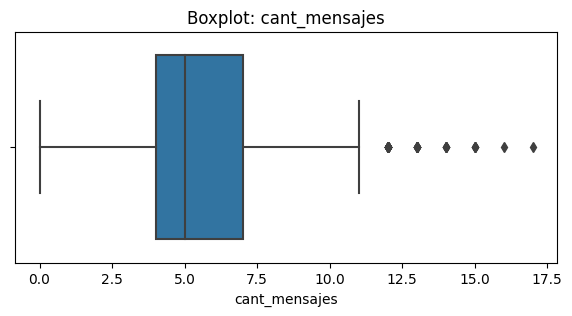

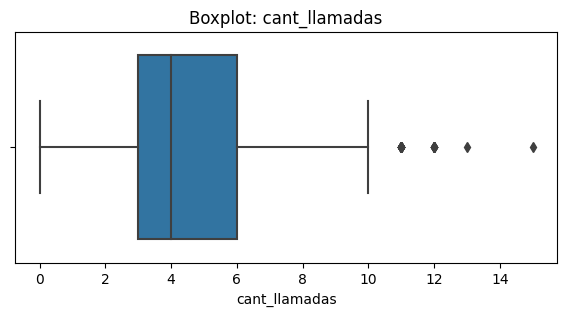

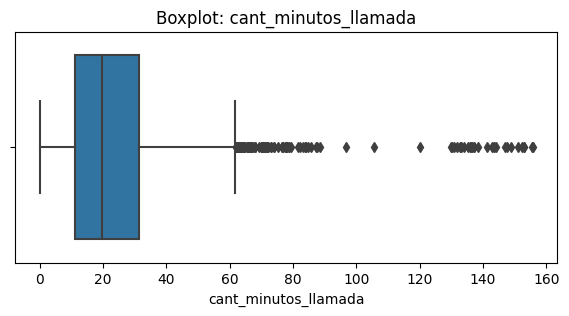

In [ ]:
# Visualizando usando BoxPlot
for col in columnas_numericas:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- `age`: No se observan outliers. Los valores se mantienen dentro de los límites esperados del boxplot, por lo que la distribución de edades no presenta valores atípicos evidentes.
- `cant_mensajes`: Sí presenta outliers en el extremo superior. Se observan varios usuarios con aproximadamente 12 a 17 mensajes, por encima del límite superior del boxplot. No se aprecian outliers inferiores.
- `cant_llamadas`: Presenta outliers únicamente en el extremo superior. Hay algunos usuarios con alrededor de 11 a 15 llamadas, superiores al comportamiento habitual.
- `cant_minutos_llamada`: Es la variable con mayor cantidad de outliers. Se observan numerosos valores por encima de aproximadamente 60 minutos, incluyendo casos extremos cercanos a 130–155 minutos. Esto confirma una distribución fuertemente sesgada a la derecha.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

Q1 = user_profile[columnas_limites].quantile(0.25)
Q3 = user_profile[columnas_limites].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

In [ ]:
# Contar outliers
outliers = (user_profile[columnas_limites] > limite_superior).sum()

# Mostrar resultados
print("Límite superior:")
print(limite_superior)
print()
print("Cantidad de outliers:")
print(outliers)

Límite superior:
cant_mensajes           11.5000
cant_llamadas           10.5000
cant_minutos_llamada    61.8575
dtype: float64

Cantidad de outliers:
cant_mensajes            46
cant_llamadas            30
cant_minutos_llamada    109
dtype: int64


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- ``cant_mensajes``: el límite superior es 11.5 y hay 46 outliers, con un máximo de 17 mensajes. Mantendría estos valores porque 12–17 mensajes sigue siendo un nivel de uso totalmente posible. Son usuarios más activos, no necesariamente datos incorrectos.
- ``cant_llamadas``: el límite superior es 10.5 y hay 30 outliers, con un máximo de 15 llamadas. También los conservaría, ya que hacer entre 11 y 15 llamadas es plausible y puede identificar clientes de mayor uso.
- ``cant_minutos_llamada``: el límite superior es aproximadamente 61.86 minutos y aparecen 109 outliers, con un máximo de 155.69 minutos. Aunque aquí los valores extremos están mucho más alejados del comportamiento típico, los mantendría porque la distribución ya mostró un fuerte sesgo a la derecha y estos casos pueden corresponder a usuarios intensivos. Antes de eliminarlos, convendría confirmar que no existen límites de negocio que hagan imposibles esos consumos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'

    elif llamadas < 10 and mensajes < 10:
        return 'Medio uso'

    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medio uso
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Medio uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def g_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'

    elif edad < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(g_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Medio uso,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Medio uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

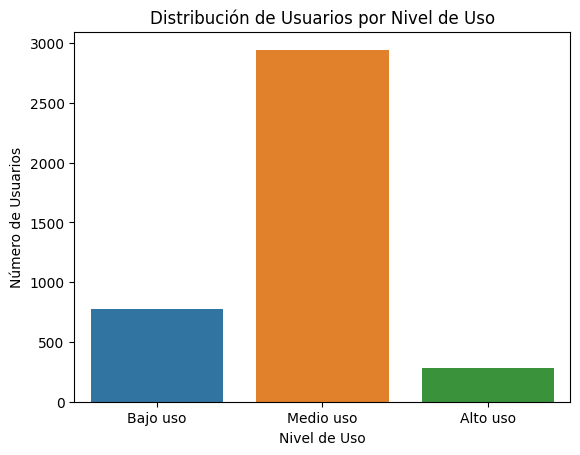

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Medio uso', 'Alto uso'],)
plt.title('Distribución de Usuarios por Nivel de Uso')
plt.xlabel('Nivel de Uso')
plt.ylabel('Número de Usuarios')
plt.show()

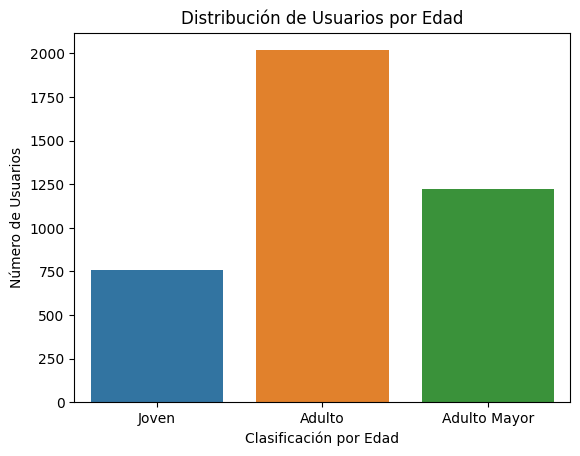

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],)
plt.title('Distribución de Usuarios por Edad')
plt.xlabel('Clasificación por Edad')
plt.ylabel('Número de Usuarios')
plt.show()

In [ ]:
tabla_edad_uso = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso'],
    normalize='index'
) * 100
print(tabla_edad_uso)

grupo_uso     Alto uso   Bajo uso  Medio uso
grupo_edad                                  
Adulto        7.631318  18.037661  74.331021
Adulto Mayor  6.055646  21.031097  72.913257
Joven         6.710526  20.657895  72.631579


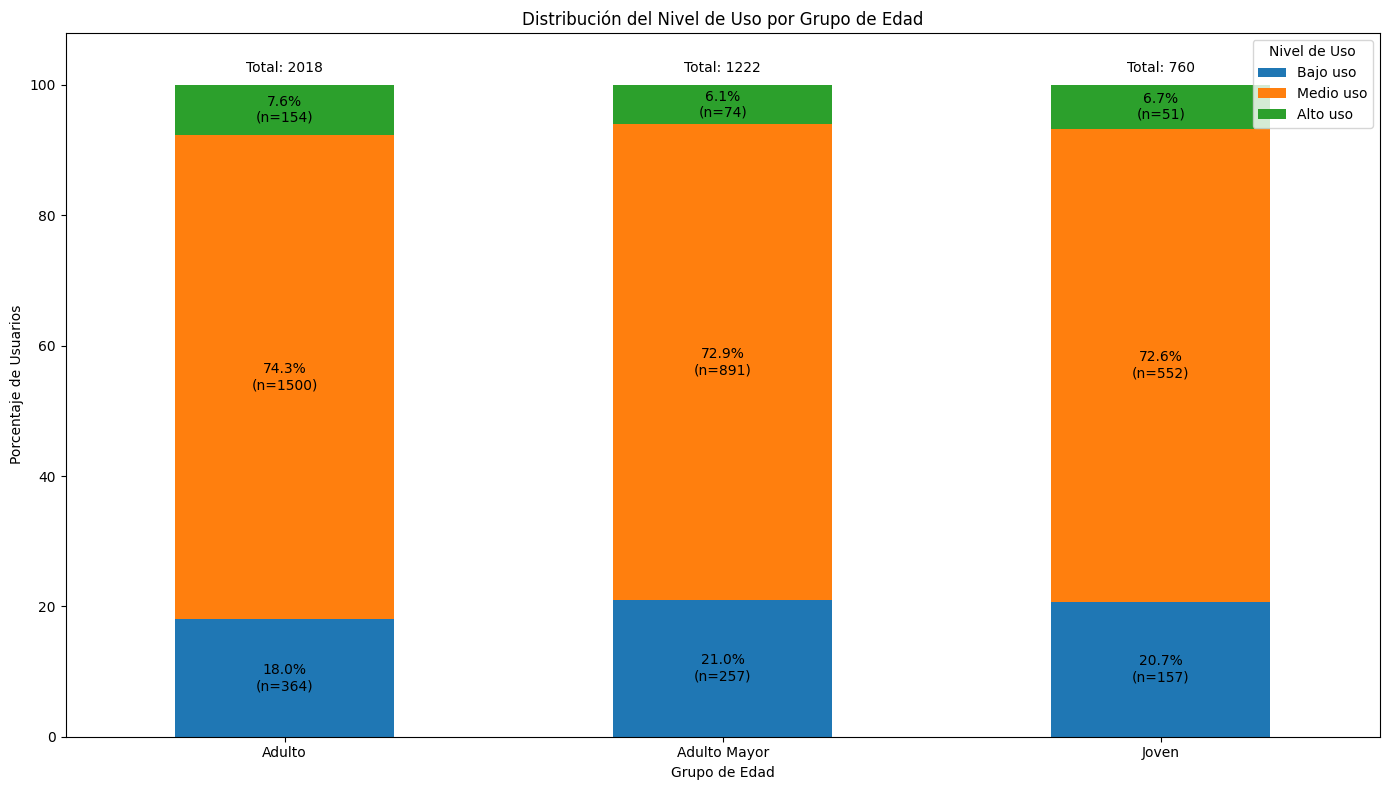

In [ ]:
# Tablas de porcentajes y cantidades
orden_uso = ['Bajo uso', 'Medio uso', 'Alto uso']

tabla_porcentaje = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso'],
    normalize='index'
)[orden_uso] * 100

tabla_conteo = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso']
)[orden_uso]


# Crear gráfica
ax = tabla_porcentaje.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8)
)

# Título y ejes
plt.title('Distribución del Nivel de Uso por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Porcentaje de Usuarios')
plt.xticks(rotation=0)
plt.legend(title='Nivel de Uso')

# Agregar porcentaje y cantidad dentro de cada segmento
for i, grupo_edad in enumerate(tabla_porcentaje.index):

    acumulado = 0

    for grupo_uso in orden_uso:

        porcentaje = tabla_porcentaje.loc[grupo_edad, grupo_uso]
        cantidad = tabla_conteo.loc[grupo_edad, grupo_uso]

        plt.text(
            i,
            acumulado + porcentaje / 2,
            f'{porcentaje:.1f}%\n(n={cantidad})',
            ha='center',
            va='center'
        )

        acumulado += porcentaje

# Total de usuarios por grupo de edad
totales = tabla_conteo.sum(axis=1)

for i, total in enumerate(totales):
    plt.text(
        i,
        102,
        f'Total: {total}',
        ha='center'
    )

plt.ylim(0, 108)
plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**

- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- ``city``: se encontraron 469 valores nulos (11.73%) y además 96 registros con "?" (2.4%), que funcionaban como sentinel. Los "?" se reemplazaron por pd.NA para estandarizar los datos faltantes.
- ``age``: se detectó el valor -999 como sentinel, ya que no corresponde a una edad válida y distorsionaba la media y la desviación estándar. Se reemplazó por la mediana de las edades válidas.
- ``reg_date``: se identificaron 40 fechas del año 2026, equivalentes al 1% de los usuarios, aunque el dataset solo contiene información hasta 2024. Estas fechas se marcaron como NaT para excluirlas de análisis temporales.
- ``usage['date']``: se encontraron 50 fechas faltantes, equivalentes al 0.125% de los 40,000 registros. Se mantuvieron como valores nulos al representar una proporción muy baja del dataset.
- ``duration y length``: duration presentó 22,076 nulos (55.19%) y length 17,896 nulos (44.74%). El análisis mostró que estos faltantes dependen de type: duration no aplica a mensajes y length no aplica a llamadas. Por ello se conservaron como nulos y no se imputaron.

🔍 **Segmentos por Edad**
- C → Los clientes se clasificaron como Jóvenes (<30), Adultos (30–59) y Adultos Mayores (≥60). F → Los Adultos forman el grupo más grande con 2,018 clientes, seguidos por 1,222 Adultos Mayores y 760 Jóvenes. Sin embargo, la composición del nivel de uso es muy similar en los tres grupos: el uso medio representa 74.3% de Adultos, 72.9% de Adultos Mayores y 72.6% de Jóvenes. I → No utilizar la edad como criterio principal para definir productos; emplearla como variable complementaria de una segmentación basada principalmente en comportamiento de consumo.
- C → Se buscó determinar si alguna generación mostraba una mayor tendencia al uso intensivo. F → Los Adultos presentan la mayor proporción de alto uso (7.6%) y también el mayor volumen absoluto, con 154 clientes, frente a 74 Adultos Mayores y 51 Jóvenes. Aun así, las diferencias porcentuales entre edades son pequeñas. I → Priorizar a los Adultos de alto uso para análisis de upselling, pero validar individualmente su plan actual antes de diseñar campañas específicas.
- C → Podría suponerse que los Jóvenes consumirían significativamente más servicios. F → Solo 6.7% pertenece al grupo de alto uso; 72.6% tiene uso medio y 20.7% bajo. I → Evitar asumir que juventud equivale a mayor consumo de llamadas o mensajes e incorporar uso de datos móviles/GB antes de diseñar propuestas específicas para este segmento.

📊 **Segmentos por Nivel de Uso**

- C → La segmentación clasificó a los clientes en Bajo, Medio y Alto uso según llamadas y mensajes. F → El uso medio domina claramente en todas las edades, mientras los clientes de alto uso representan una minoría. Esto indica que el cliente típico de ConnectaTel tiene un comportamiento moderado, no extremo. I → Utilizar al segmento de uso medio como referencia principal para evaluar si la oferta actual de planes está correctamente dimensionada.
- C → Los usuarios de alto consumo son menos numerosos, pero pueden tener mayor relevancia comercial. F → La gráfica identifica 154 Adultos, 74 Adultos Mayores y 51 Jóvenes de alto uso, es decir, un grupo reducido pero claramente diferenciable. I → Cruzar ``grupo_uso`` con ``plan`` y ``churn_date`` para identificar usuarios con plan Básico de alto uso para migrarlos a un plan Premium y clientes Premium intensivos que requieran acciones de retención.
- C → Actualmente el plan Básico representa 64.875% de la base y Premium 35.125%; Premium tiene una mensualidad mayor. F → En las distribuciones analizadas de llamadas y mensajes no se observa una diferencia fuerte de comportamiento entre ambos planes. I → Investigar qué variable realmente diferencia la elección de Premium —especialmente GB utilizados— antes de concluir que los límites actuales de llamadas o mensajes justifican el salto de precio.

💡 **Recomendaciones**

- Priorizar una segmentación conductual basada en nivel de uso, plan contratado y churn, utilizando la edad solo como variable complementaria.
- Analizar específicamente a los clientes de alto uso que aún están en el plan Básico para identificar oportunidades de migración a Premium.
- Revisar a los usuarios Premium de alto uso como grupo prioritario para retención, ya que representan clientes potencialmente valiosos por su mayor consumo y cuota mensual.
- Evaluar la creación de un plan intermedio entre Básico y Premium si el análisis mensual confirma que muchos usuarios de uso medio superan o se acercan a los límites del Básico sin requerir toda la capacidad del Premium.
- Incorporar al análisis el consumo de datos móviles (GB), ya que las diferencias observadas en llamadas y mensajes entre Básico y Premium son pequeñas y podrían no explicar por sí solas la elección del plan.
- Analizar el consumo a nivel usuario-mes antes de comparar el uso con los límites incluidos en cada plan, ya que actualmente las métricas de uso están agregadas para todo 2024.
- Mantener los outliers plausibles como parte del análisis y tratarlos como posibles usuarios intensivos, en lugar de eliminarlos automáticamente.
- Fortalecer las validaciones de captura en campos como age, city y reg_date para reducir sentinels, valores faltantes y fechas fuera de rango en futuras bases.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`